# Wind Data Validation

Checks whether Open-Meteo ERA5 wind speeds, passed through our parametric power curve,
reproduce real measured offshore generation.

## Two independent tests

| Test | Wind source | Farm modelled | Compared against |
|------|-------------|---------------|------------------|
| **A** | Open-Meteo API fetch — WFA location (41.85°N, 9.03°W) | WindFloat Atlantic — 3 × Vestas V164-8.4 MW = **25.2 MW** | Portugal actual offshore (ENTSO-E) |
| **B** | Already-downloaded Alpha Ventus ERA5 file | Alpha Ventus fleet-representative CF × German installed offshore capacity | Germany actual offshore (Frauenhofer) |

Test A is the tightest check: WFA is Portugal's **only** offshore wind farm, so the comparison is 1:1.
Test B is looser (one met mast representing ~8 GW spread across the German Bight) but still useful as a sanity check.

In [66]:
import sys, importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy import stats

# Make src/ importable from the 3.2 folder
MODEL_ROOT = Path().resolve().parent          # …/3.2 system model v2/
if str(MODEL_ROOT) not in sys.path:
    sys.path.insert(0, str(MODEL_ROOT))

# Force reload so updated generation.py is picked up without kernel restart
import src.models.generation as _gen_mod
importlib.reload(_gen_mod)
from src.models.generation import power_curve_parametric, power_curve_v164, extrapolate_wind_speed

from src.data.loaders import (
    load_alpha_ventus_wind,
    load_frauenhofer,
    load_pt_generation,
    load_capacity_all,
)

YEAR = 2024
print('Imports OK')

Imports OK


---
## Test A — WindFloat Atlantic vs Portugal actual offshore

In [67]:
# ── Fetch WFA wind data from Open-Meteo ───────────────────────────────────
# WFA is ~20 km off Viana do Castelo; ERA5 grid snaps to nearest 0.25° cell
WFA_LAT, WFA_LON = 41.85, -9.03

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={WFA_LAT}&longitude={WFA_LON}"
    f"&start_date={YEAR}-01-01&end_date={YEAR}-12-31"
    "&hourly=wind_speed_100m"
    "&wind_speed_unit=ms"
)

resp = requests.get(url, timeout=30)
resp.raise_for_status()
data = resp.json()

wfa_wind = pd.DataFrame({
    "timestamp":     pd.to_datetime(data["hourly"]["time"]),
    "wind_speed_ms": data["hourly"]["wind_speed_100m"],
})

print(f"Fetched {len(wfa_wind):,} hourly rows")
print(f"ERA5 grid cell snapped to: {data['latitude']:.3f}°N, {data['longitude']:.3f}°E")
print(f"Wind speed: mean {wfa_wind.wind_speed_ms.mean():.2f} m/s, "
      f"max {wfa_wind.wind_speed_ms.max():.1f} m/s")

Fetched 8,784 hourly rows
ERA5 grid cell snapped to: 41.793°N, -8.870°E
Wind speed: mean 6.80 m/s, max 23.2 m/s


In [68]:
# ── Vestas V164-8.4 MW turbine specs (WFA) ────────────────────────────────
# 3 turbines × 8.4 MW = 25.2 MW gross nameplate
WFA_CAPACITY_MW = 25.2
RATED = 14.0   # m/s — kept for reference in table output
HUB_HEIGHT = 110.0
REF_HEIGHT = 100.0
Z0 = 0.0002   # open sea roughness

# Use nameplate capacity directly. ENTSO-E data already includes all real losses.
WFA_EFFECTIVE_CAPACITY_MW = WFA_CAPACITY_MW

# Height-correct wind speed: 100 m -> 110 m hub
v_hub = extrapolate_wind_speed(
    wfa_wind["wind_speed_ms"].values,
    z_ref=REF_HEIGHT, z_hub=HUB_HEIGHT, z0=Z0
)

# Use tabulated V164-8.4 MW power curve (replaces inaccurate cubic parametric)
cf = power_curve_v164(v_hub)

wfa_wind["wind_speed_hub_ms"] = v_hub
wfa_wind["cf"] = cf
wfa_wind["modelled_mwh"] = cf * WFA_EFFECTIVE_CAPACITY_MW

print(f"Mean CF: {cf.mean()*100:.1f}%")
print(f"Nameplate capacity used: {WFA_EFFECTIVE_CAPACITY_MW:.2f} MW")
print(f"Annual modelled generation: {wfa_wind.modelled_mwh.sum()/1e3:.1f} GWh")

Mean CF: 42.7%
Nameplate capacity used: 25.20 MW
Annual modelled generation: 94.5 GWh


In [69]:
# ── Load Portugal actual offshore (ENTSO-E) ───────────────────────────────
pt_gen = load_pt_generation(YEAR)

# Timestamp alignment note:
# - Open-Meteo archive times are UTC.
# - ENTSO-E PT file is labelled "MTU (CET/CEST)".
# Convert CET/CEST -> UTC before merge. Use ambiguous='NaT' for DST fallback
# to avoid crashes when repeated-hour information is incomplete.
pt_ts = pd.to_datetime(pt_gen["timestamp"], errors="coerce")
pt_ts = pt_ts.dt.tz_localize("Europe/Berlin", ambiguous="NaT", nonexistent="shift_forward")
pt_ts = pt_ts.dt.tz_convert("UTC").dt.tz_localize(None)
pt_gen["timestamp"] = pt_ts

wfa_ts = pd.to_datetime(wfa_wind["timestamp"], errors="coerce")
wfa_ts = wfa_ts.dt.tz_localize("UTC").dt.tz_localize(None)
wfa_wind["timestamp"] = wfa_ts

# Drop rows that became NaT during DST disambiguation/parsing
pt_gen = pt_gen.dropna(subset=["timestamp"]).reset_index(drop=True)
wfa_wind = wfa_wind.dropna(subset=["timestamp"]).reset_index(drop=True)

merged_a = pd.merge(wfa_wind, pt_gen, on="timestamp", how="inner").dropna()

print(f"Merged rows: {len(merged_a):,}")
print(f"Portugal actual offshore: mean {merged_a.generation_mwh.mean():.1f} MWh/h, "
      f"annual {merged_a.generation_mwh.sum()/1e3:.1f} GWh")

Merged rows: 8,779
Portugal actual offshore: mean 9.8 MWh/h, annual 86.0 GWh


In [70]:
# ── Correlation & R² — Test A ─────────────────────────────────────────────
x_a = merged_a["modelled_mwh"].values
y_a = merged_a["generation_mwh"].values

slope_a, intercept_a, r_a, p_a, _ = stats.linregress(x_a, y_a)
r2_a = r_a**2

print("Test A — WFA modelled vs Portugal actual offshore")
print(f"  R²      = {r2_a:.4f}")
print(f"  r       = {r_a:.4f}")
print(f"  slope   = {slope_a:.3f}  (ideal = 1.0)")
print(f"  intercept = {intercept_a:.2f} MWh")

Test A — WFA modelled vs Portugal actual offshore
  R²      = 0.6859
  r       = 0.8282
  slope   = 0.818  (ideal = 1.0)
  intercept = 1.00 MWh


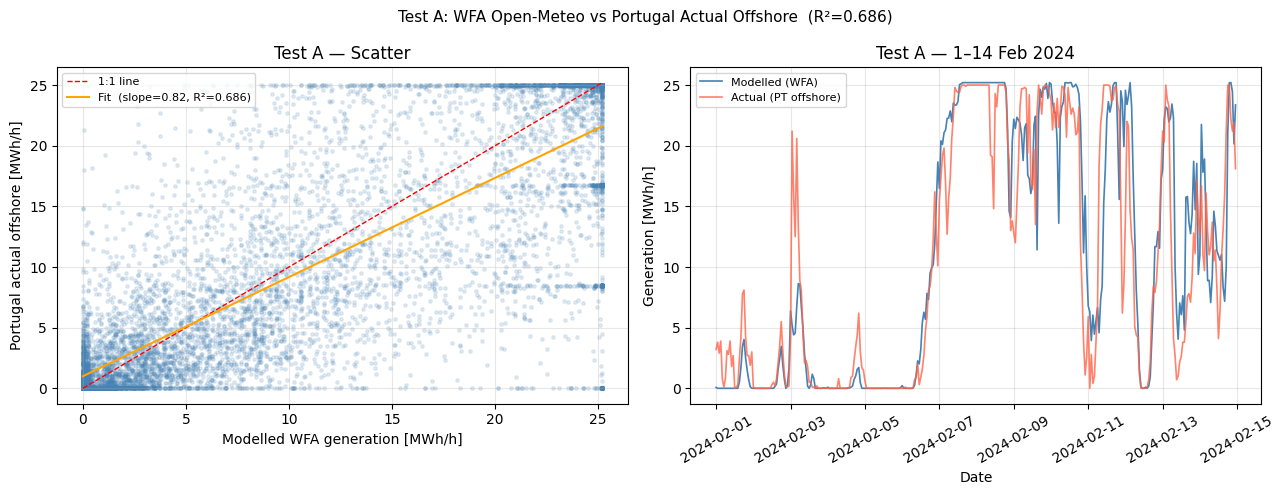

In [71]:
# ── Plot Test A ───────────────────────────────────────────────────────────
PLOT_START = f"{YEAR}-02-01"
PLOT_END   = f"{YEAR}-02-15"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
ax = axes[0]
ax.scatter(x_a, y_a, alpha=0.15, s=6, color='steelblue')
xlim = max(x_a.max(), y_a.max())
ax.plot([0, xlim], [0, xlim], 'r--', lw=1, label='1:1 line')
fit_x = np.linspace(0, xlim, 100)
ax.plot(fit_x, slope_a * fit_x + intercept_a, 'orange', lw=1.5,
        label=f'Fit  (slope={slope_a:.2f}, R²={r2_a:.3f})')
ax.set_xlabel('Modelled WFA generation [MWh/h]')
ax.set_ylabel('Portugal actual offshore [MWh/h]')
ax.set_title('Test A — Scatter')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Time series — first 2 weeks of February
ax = axes[1]
subset = merged_a[(merged_a['timestamp'] >= PLOT_START) & (merged_a['timestamp'] < PLOT_END)].copy()
ax.plot(subset['timestamp'], subset['modelled_mwh'], label='Modelled (WFA)', color='steelblue', lw=1.2)
ax.plot(subset['timestamp'], subset['generation_mwh'], label='Actual (PT offshore)', color='tomato', lw=1.2, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Generation [MWh/h]')
ax.set_title(f'Test A — 1–14 Feb {YEAR}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30)

fig.suptitle(f'Test A: WFA Open-Meteo vs Portugal Actual Offshore  (R²={r2_a:.3f})', fontsize=11)
plt.tight_layout()
plt.show()

In [72]:
# ── Table: plotted window with wind speed ─────────────────────────────────
# Shows hub-height wind speed alongside modelled and actual output so you can
# verify that high-wind hours (>= RATED m/s) reach the expected 25.2 MWh/h.
tbl = subset[["timestamp", "wind_speed_hub_ms", "cf", "modelled_mwh", "generation_mwh"]].copy()
tbl.columns = ["timestamp", "wind_hub_ms", "CF", "modelled_MWh", "actual_MWh"]
tbl = tbl.reset_index(drop=True)

pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_rows", len(tbl))
print(f"Plotted window: {PLOT_START} → {PLOT_END}  (rated speed = {RATED} m/s, nameplate = {WFA_EFFECTIVE_CAPACITY_MW} MW)")
print(tbl.to_string(index=False))

Plotted window: 2024-02-01 → 2024-02-15  (rated speed = 14.0 m/s, nameplate = 25.2 MW)
          timestamp  wind_hub_ms   CF  modelled_MWh  actual_MWh
2024-02-01 00:00:00         2.26 0.00          0.07        3.20
2024-02-01 01:00:00         1.54 0.00          0.00        3.80
2024-02-01 02:00:00         1.37 0.00          0.00        2.90
2024-02-01 03:00:00         1.21 0.00          0.00        3.90
2024-02-01 04:00:00         1.22 0.00          0.00        0.80
2024-02-01 05:00:00         0.82 0.00          0.00        0.10
2024-02-01 06:00:00         0.67 0.00          0.00        0.80
2024-02-01 07:00:00         0.51 0.00          0.00        3.10
2024-02-01 08:00:00         1.11 0.00          0.00        2.80
2024-02-01 09:00:00         1.50 0.00          0.00        3.90
2024-02-01 10:00:00         1.29 0.00          0.00        1.80
2024-02-01 11:00:00         0.64 0.00          0.00        2.70
2024-02-01 12:00:00         0.50 0.00          0.00        0.00
2024-02-01 13:00:

---
## Test B — Alpha Ventus CF × Germany installed capacity vs Germany actual offshore

In [73]:
# ── Load Alpha Ventus wind (already downloaded ERA5 file) ─────────────────
av_wind = load_alpha_ventus_wind(year=YEAR)
av_wind["timestamp"] = av_wind["timestamp"].dt.tz_localize(None)

# Alpha Ventus turbines: mix of Adwen M5000-116 and Senvion 5M
# For fleet scaling, avoid hard CF=1 plateaus by using conservative rated speed.
AV_CUT_IN, AV_RATED, AV_CUT_OUT = 3.5, 14.0, 25.0
AV_HUB = 92.0

v_hub_av = extrapolate_wind_speed(
    av_wind["wind_speed_ms"].values,
    z_ref=100.0, z_hub=AV_HUB, z0=Z0
)
cf_av = power_curve_parametric(v_hub_av, cut_in_ms=AV_CUT_IN, rated_speed_ms=AV_RATED, cut_out_ms=AV_CUT_OUT)

# Fleet realism correction:
# 1) use monthly installed offshore capacity (not fixed annual 8.1 GW)
# 2) use net fleet factor to represent outages/wake/electrical losses
cap = load_capacity_all().copy()
cap = cap[(cap["year_num"] == YEAR) & cap["month_num"].between(1, 12)].copy()
cap = cap[["month_num", "Wind offshore"]].rename(columns={"Wind offshore": "cap_gw"})

av_wind["month_num"] = av_wind["timestamp"].dt.month
av_wind = av_wind.merge(cap, on="month_num", how="left")

DE_NET_FLEET_FACTOR = 0.90
av_wind["cf"] = cf_av
av_wind["modelled_mwh"] = cf_av * av_wind["cap_gw"] * 1000.0 * DE_NET_FLEET_FACTOR

print(f"Alpha Ventus mean CF: {cf_av.mean()*100:.1f}%")
print(f"Mean monthly DE capacity used: {av_wind['cap_gw'].mean():.2f} GW")
print(f"Net fleet factor used: {DE_NET_FLEET_FACTOR:.2f}")
print(f"Modelled DE offshore annual: {av_wind.modelled_mwh.sum()/1e6:.2f} TWh")

Alpha Ventus mean CF: 40.4%
Mean monthly DE capacity used: 8.87 GW
Net fleet factor used: 0.90
Modelled DE offshore annual: 28.20 TWh


In [74]:
# ── Load Germany actual offshore (Frauenhofer) ────────────────────────────
de_gen = load_frauenhofer(YEAR)
de_gen["timestamp"] = pd.to_datetime(de_gen["timestamp"])

merged_b = pd.merge(av_wind, de_gen, on="timestamp", how="inner").dropna()

# Frauenhofer returns MWh/h for the whole fleet
x_b = merged_b["modelled_mwh"].values
y_b = merged_b["generation_mwh"].values

slope_b, intercept_b, r_b, p_b, _ = stats.linregress(x_b, y_b)
r2_b = r_b**2

# Diagnose possible timing mismatch: test lags from -24h to +24h
lag_scan_b = []
for lag in range(-24, 25):
    r_lag = merged_b["modelled_mwh"].shift(lag).corr(merged_b["generation_mwh"])
    lag_scan_b.append((lag, r_lag))

best_lag_b, best_r_b = max(lag_scan_b, key=lambda x: abs(x[1]) if pd.notna(x[1]) else -1)
best_r2_b = best_r_b**2 if pd.notna(best_r_b) else np.nan

print(f"Merged rows: {len(merged_b):,}")
print("Test B — Alpha Ventus CF × fleet vs Germany actual")
print(f"  R² (no lag)   = {r2_b:.4f}")
print(f"  r  (no lag)   = {r_b:.4f}")
print(f"  slope         = {slope_b:.3f}  (ideal = 1.0)")
print(f"  Best lag      = {best_lag_b:+d} h")
print(f"  R² (best lag) = {best_r2_b:.4f}")

Merged rows: 8,783
Test B — Alpha Ventus CF × fleet vs Germany actual
  R² (no lag)   = 0.5958
  r  (no lag)   = 0.7719
  slope         = 0.512  (ideal = 1.0)
  Best lag      = +0 h
  R² (best lag) = 0.5958


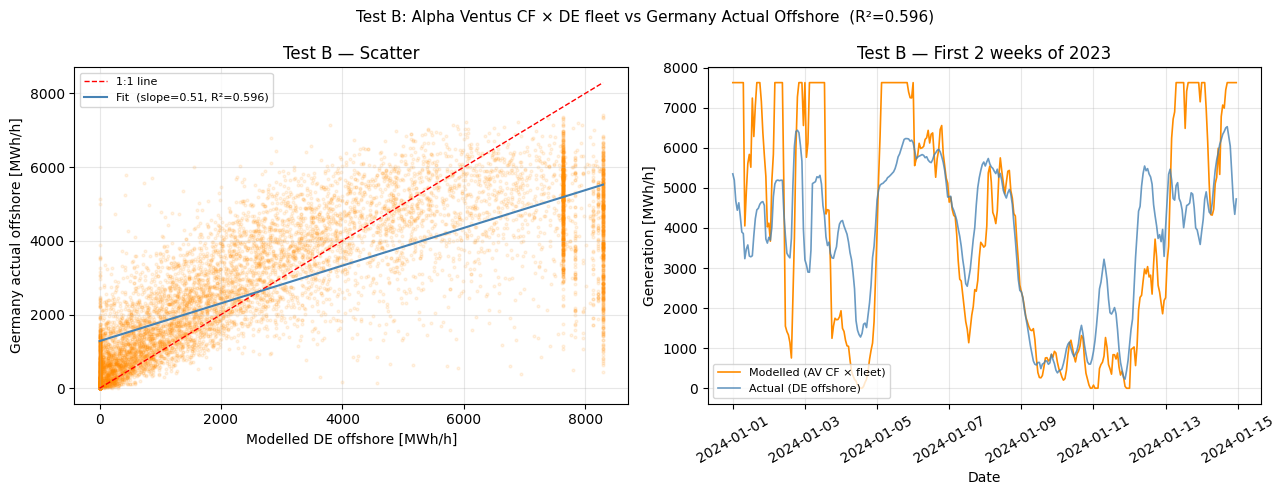

In [75]:
# ── Plot Test B ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(x_b, y_b, alpha=0.1, s=4, color='darkorange')
xlim_b = max(x_b.max(), y_b.max())
ax.plot([0, xlim_b], [0, xlim_b], 'r--', lw=1, label='1:1 line')
fit_x_b = np.linspace(0, xlim_b, 100)
ax.plot(fit_x_b, slope_b * fit_x_b + intercept_b, 'steelblue', lw=1.5,
        label=f'Fit  (slope={slope_b:.2f}, R²={r2_b:.3f})')
ax.set_xlabel('Modelled DE offshore [MWh/h]')
ax.set_ylabel('Germany actual offshore [MWh/h]')
ax.set_title('Test B — Scatter')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
subset_b = merged_b.head(24*14)
ax.plot(subset_b['timestamp'], subset_b['modelled_mwh'], label='Modelled (AV CF × fleet)', color='darkorange', lw=1.2)
ax.plot(subset_b['timestamp'], subset_b['generation_mwh'], label='Actual (DE offshore)', color='steelblue', lw=1.2, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Generation [MWh/h]')
ax.set_title('Test B — First 2 weeks of 2023')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30)

fig.suptitle(f'Test B: Alpha Ventus CF × DE fleet vs Germany Actual Offshore  (R²={r2_b:.3f})', fontsize=11)
plt.tight_layout()
plt.show()

---
## Summary

| Test | R² | What it means |
|------|-----|---------------|
| A — WFA vs PT actual | — | **1:1 check**: ERA5 + power curve reproducing real single-farm output |
| B — AV CF × fleet vs DE actual | — | **Fleet proxy**: one wind mast representing ~8 GW spread across North Sea |

**Interpreting R²:**
- > 0.85 → good correlation, wind data is reliable for the model
- 0.70–0.85 → acceptable; residual spread is likely due to spatial diversity or capacity ramping
- < 0.70 → investigate data alignment or turbine spec mismatch

**Expected outcome for Test A:** R² should be high (≥ 0.85) since WFA is the only farm.  
**Expected outcome for Test B:** R² will be lower — Alpha Ventus is a single point representing a spatially diverse fleet, so geographic smoothing in the real data is not captured.